# ROI Size Analysis

## Objective

This notebook evaluates the size of the pancreas relative to the fixed ROI used by the preprocessing pipeline.

The purpose is to determine whether the selected ROI provides reasonable spatial coverage for the pancreas and surrounding anatomy before 3D model training.

This is a dataset-level analysis rather than a model experiment.

## Why this matters

The classifier will not receive the entire CT volume. It receives a fixed-size 3D region centered on the pancreas.

Therefore, the ROI must be large enough to contain the relevant pancreatic anatomy while also providing surrounding anatomical context.

The analysis will compare:

- pancreas bounding-box dimensions
- fixed ROI dimensions
- pancreas-to-ROI size ratios
- physical dimensions in millimeters

No PDAC lesion annotation is used to determine the ROI size.

In [1]:
# ============================================================
# Imports and project configuration
# ============================================================

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"D:\Pancreatic_Cancer_Thesis")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    DEFAULT_ROI_SIZE,
    DEFAULT_TARGET_SPACING,
    analyze_roi_sizes,
)

print("Project root:", PROJECT_ROOT)
print("ROI size (voxels):", DEFAULT_ROI_SIZE)
print("Target spacing (mm):", DEFAULT_TARGET_SPACING)

Project root: D:\Pancreatic_Cancer_Thesis
ROI size (voxels): (128, 160, 192)
Target spacing (mm): (1.0, 1.0, 3.0)


## Understanding the ROI dimensions

The ROI is specified in voxels, not millimeters.

Because preprocessing resamples the data to a target spacing of:

1.0 mm × 1.0 mm × 3.0 mm

the physical dimensions of the ROI are:

- depth = 128 × 3.0 mm
- height = 160 × 1.0 mm
- width = 192 × 1.0 mm

This calculation lets us interpret the ROI in anatomical rather than purely computational terms.

In [2]:
# ============================================================
# Convert ROI size from voxels to millimeters
# ============================================================

roi_voxels = np.array(DEFAULT_ROI_SIZE, dtype=float)
spacing_mm = np.array(DEFAULT_TARGET_SPACING, dtype=float)

roi_mm = roi_voxels * spacing_mm

print("ROI dimensions:")
print(f"  Depth : {roi_voxels[0]:.0f} voxels = {roi_mm[0]:.1f} mm")
print(f"  Height: {roi_voxels[1]:.0f} voxels = {roi_mm[1]:.1f} mm")
print(f"  Width : {roi_voxels[2]:.0f} voxels = {roi_mm[2]:.1f} mm")

ROI dimensions:
  Depth : 128 voxels = 128.0 mm
  Height: 160 voxels = 160.0 mm
  Width : 192 voxels = 576.0 mm


## Measure pancreas dimensions across the dataset

The existing preprocessing code provides `analyze_roi_sizes()`.

For label 4, it calculates the bounding-box dimensions of the pancreas after resampling to the target spacing.

The resulting dataset describes how large the pancreas appears in:

- depth
- height
- width
- bounding-box volume

These measurements are used only for analysis.

In [3]:
# ============================================================
# Analyze pancreas dimensions
# ============================================================

pancreas_sizes = analyze_roi_sizes(
    label=4,
    target_spacing=DEFAULT_TARGET_SPACING,
    progress_every=100,
)

print("\nNumber of pancreas measurements:", len(pancreas_sizes))

display(pancreas_sizes.head())

100/536
200/536
300/536
400/536
500/536
536/536

Number of pancreas measurements: 536


,study_id,depth,height,width,volume
0,100936_00001,14,63,133,117306
1,101691_00001,34,80,130,353600
2,101692_00001,28,62,115,199640
3,101693_00001,42,74,108,335664
4,101694_00001,33,60,120,237600


In [5]:
# ============================================================
# Summary statistics
# ============================================================

summary = pancreas_sizes[
    ["depth", "height", "width", "volume"]
].describe().T

display(summary)

,count,mean,std,min,25%,50%,75%,max
depth,536.0,27.513060,4.786255,11.0,24.0,28.0,30.0,45.0
height,536.0,72.169776,15.393988,28.0,62.0,70.0,82.0,134.0
width,536.0,123.645522,22.242363,48.0,109.0,124.0,139.0,220.0
volume,536.0,253268.574627,105457.355486,45880.0,182970.0,236382.0,315442.5,864032.0


## Compare pancreas size with the fixed ROI

A simple way to interpret the results is to calculate the fraction of the ROI occupied by the pancreas bounding box.

This is not the fraction of actual pancreas volume.

It compares the pancreas bounding-box dimensions with the fixed ROI dimensions.

A lower ratio generally means more spatial room exists around the pancreas.

In [6]:
# ============================================================
# Pancreas-to-ROI dimensional ratios
# ============================================================

pancreas_sizes["depth_ratio"] = (
    pancreas_sizes["depth"] / DEFAULT_ROI_SIZE[0]
)

pancreas_sizes["height_ratio"] = (
    pancreas_sizes["height"] / DEFAULT_ROI_SIZE[1]
)

pancreas_sizes["width_ratio"] = (
    pancreas_sizes["width"] / DEFAULT_ROI_SIZE[2]
)

display(
    pancreas_sizes[
        [
            "depth_ratio",
            "height_ratio",
            "width_ratio",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
depth_ratio,536.0,0.214946,0.037393,0.085938,0.187500,0.218750,0.234375,0.351562
height_ratio,536.0,0.451061,0.096212,0.175000,0.387500,0.437500,0.512500,0.837500
width_ratio,536.0,0.643987,0.115846,0.250000,0.567708,0.645833,0.723958,1.145833


In [7]:
# ============================================================
# Physical pancreas bounding-box dimensions
# ============================================================

pancreas_sizes["depth_mm"] = (
    pancreas_sizes["depth"] * DEFAULT_TARGET_SPACING[0]
)

pancreas_sizes["height_mm"] = (
    pancreas_sizes["height"] * DEFAULT_TARGET_SPACING[1]
)

pancreas_sizes["width_mm"] = (
    pancreas_sizes["width"] * DEFAULT_TARGET_SPACING[2]
)

display(
    pancreas_sizes[
        [
            "depth_mm",
            "height_mm",
            "width_mm",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
depth_mm,536.0,27.513060,4.786255,11.0,24.0,28.0,30.0,45.0
height_mm,536.0,72.169776,15.393988,28.0,62.0,70.0,82.0,134.0
width_mm,536.0,370.936567,66.727089,144.0,327.0,372.0,417.0,660.0


## Interpretation

The fixed ROI should be interpreted as a context window around the pancreas rather than as a tight segmentation box.

The purpose of this analysis is not to prove that the selected ROI is optimal.

Instead, it provides evidence that the chosen dimensions are large enough relative to the observed pancreas dimensions to make the fixed-size ROI a reasonable starting point for 3D classification.

The model itself will later provide empirical evidence through validation and test performance.

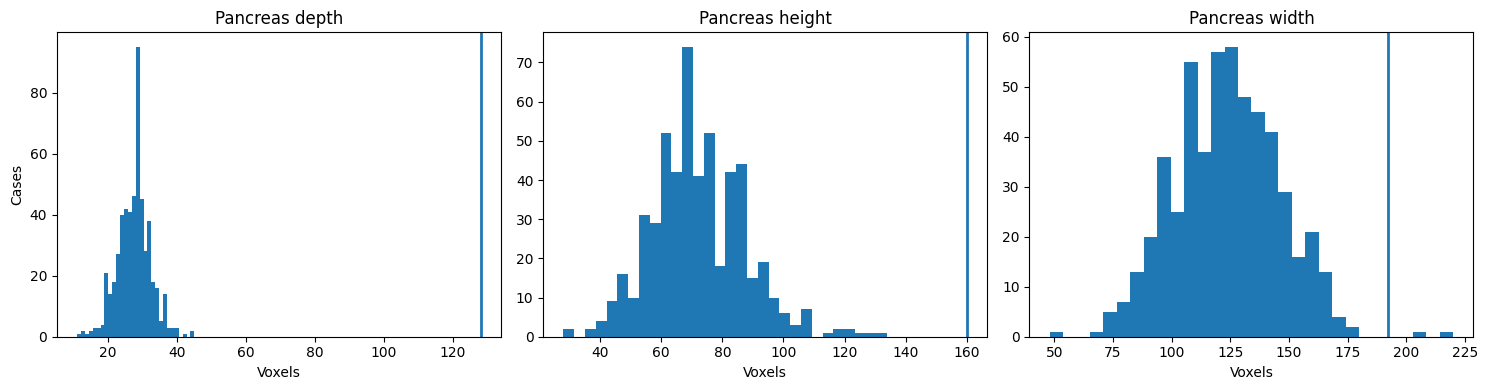

In [8]:
# ============================================================
# Distribution of pancreas bounding-box dimensions
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(pancreas_sizes["depth"], bins=30)
axes[0].axvline(DEFAULT_ROI_SIZE[0], linewidth=2)
axes[0].set_title("Pancreas depth")
axes[0].set_xlabel("Voxels")
axes[0].set_ylabel("Cases")

axes[1].hist(pancreas_sizes["height"], bins=30)
axes[1].axvline(DEFAULT_ROI_SIZE[1], linewidth=2)
axes[1].set_title("Pancreas height")
axes[1].set_xlabel("Voxels")

axes[2].hist(pancreas_sizes["width"], bins=30)
axes[2].axvline(DEFAULT_ROI_SIZE[2], linewidth=2)
axes[2].set_title("Pancreas width")
axes[2].set_xlabel("Voxels")

plt.tight_layout()
plt.show()

# Conclusion

The fixed ROI used by the preprocessing pipeline is:

128 × 160 × 192 voxels

which corresponds to:

384 × 160 × 192 mm

at the target spacing of:

1.0 × 1.0 × 3.0 mm.

The pancreas-size analysis provides a dataset-level comparison between the observed pancreas dimensions and the selected fixed ROI.

This analysis is used to justify the ROI as a reasonable starting configuration for model development.

The ROI will not be changed solely on the basis of this analysis. Final suitability will also be evaluated through model training, validation performance, and explainability analysis.